# Funnel Segment Analysis

This notebook evaluates whether purchase-funnel conversion differs meaningfully across device and acquisition segments. It extends the BigQuery funnel pipeline with confidence intervals, two-proportion z-tests, multiple-testing correction, and logistic regression.

## Business questions

1. Do mobile and desktop product-view sessions convert at different rates?
2. Do Google organic and Google CPC sessions convert at different rates?
3. Which observed segment differences remain statistically credible after accounting for uncertainty?
4. Are any apparent channel advantages more likely to reflect attribution or tracking issues than product performance?

## 1. Setup

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

In [20]:
def format_p_value(value):
    return "<0.0001" if value < 0.0001 else f"{value:.4f}"

## 2. Load validated funnel segment data

The input will come from the validated BigQuery tables produced by `sql/02_funnel_analysis.sql`.

In [21]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

# Authenticate with the Google account that owns the BigQuery project.
auth.authenticate_user()

PROJECT_ID = "product-analytics-hv"
client = bigquery.Client(project=PROJECT_ID, location="US")

segment_query = """
SELECT *
FROM `product-analytics-hv.product_analytics.funnel_segment_statistics`
ORDER BY segment_type, view_to_purchase_conversion_pct DESC
"""

session_query = """
SELECT
  session_id,
  user_pseudo_id,
  session_date,
  device_category,
  traffic_source,
  traffic_medium,
  added_to_cart,
  began_checkout,
  purchased
FROM `product-analytics-hv.product_analytics.funnel_sessions`
"""

segment_stats = client.query(segment_query).to_dataframe()
funnel_sessions = client.query(session_query).to_dataframe()

print("Segment rows:", len(segment_stats))
print("Funnel sessions:", len(funnel_sessions))

display(segment_stats.head())
display(funnel_sessions.head())

Segment rows: 11
Funnel sessions: 77020


,segment_type,segment_value,product_view_sessions,cart_sessions,checkout_sessions,purchase_sessions,view_to_cart_conversion_pct,cart_to_checkout_conversion_pct,checkout_to_purchase_conversion_pct,view_to_purchase_conversion_pct,view_to_purchase_ci_lower_pct,view_to_purchase_ci_upper_pct,difference_vs_overall_percentage_points,relative_lift_vs_overall_pct,purchase_revenue_usd,revenue_per_product_view_session_usd
0,Device category,mobile,30501,6070,2194,1172,19.9000,36.1400,53.4200,3.8400,3.6300,4.0600,0.1600,4.4300,"80,981.0000",2.6600
1,Device category,tablet,1700,321,113,61,18.8800,35.2000,53.9800,3.5900,2.8000,4.5800,-0.0900,-2.4800,"3,686.0000",2.1700
2,Device category,desktop,44819,8776,3109,1601,19.5800,35.4300,51.5000,3.5700,3.4000,3.7500,-0.1100,-2.9200,"118,189.0000",2.6400
3,First-user source / medium,(data deleted) / (data deleted),5656,1449,634,388,25.6200,43.7500,61.2000,6.8600,6.2300,7.5500,3.1800,86.4300,"25,181.0000",4.4500
4,First-user source / medium,shop.googlemerchandisestore.com / referral,6634,1458,580,342,21.9800,39.7800,58.9700,5.1600,4.6500,5.7100,1.4800,40.1100,"25,646.0000",3.8700


,session_id,user_pseudo_id,session_date,device_category,traffic_source,traffic_medium,added_to_cart,began_checkout,purchased
0,1180969.1200240170-1042027522,1180969.1200240170,2020-12-15,desktop,(data deleted),(data deleted),0,0,0
1,44744021.1123310727-2884870040,44744021.1123310727,2020-12-17,desktop,shop.googlemerchandisestore.com,referral,0,0,0
2,6645818.5963001849-2327042592,6645818.5963001849,2020-12-04,desktop,(data deleted),(data deleted),0,0,0
3,65442550.0731005710-6473271300,65442550.0731005710,2020-12-07,desktop,(data deleted),(data deleted),0,0,0
4,2028522.0201942206-8863217993,2028522.0201942206,2020-12-12,desktop,(data deleted),(data deleted),0,0,0


## 3. Review segment counts and conversion rates

In [22]:
# Create readable acquisition labels for session-level comparisons.
funnel_sessions["source_medium"] = (
    funnel_sessions["traffic_source"].fillna("(direct)")
    + " / "
    + funnel_sessions["traffic_medium"].fillna("(none)")
)

device_summary = (
    segment_stats[
        segment_stats["segment_type"] == "Device category"
    ]
    .sort_values(
        "view_to_purchase_conversion_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

channel_summary = (
    segment_stats[
        segment_stats["segment_type"]
        == "First-user source / medium"
    ]
    .query(
        "segment_value != '(data deleted) / (data deleted)'"
    )
    .sort_values(
        "view_to_purchase_conversion_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Device performance")
display(
    device_summary[
        [
            "segment_value",
            "product_view_sessions",
            "purchase_sessions",
            "view_to_purchase_conversion_pct",
            "view_to_purchase_ci_lower_pct",
            "view_to_purchase_ci_upper_pct",
            "revenue_per_product_view_session_usd",
        ]
    ]
)

print("Identified acquisition-source performance")
display(
    channel_summary[
        [
            "segment_value",
            "product_view_sessions",
            "purchase_sessions",
            "view_to_purchase_conversion_pct",
            "view_to_purchase_ci_lower_pct",
            "view_to_purchase_ci_upper_pct",
            "revenue_per_product_view_session_usd",
        ]
    ]
)

Device performance


,segment_value,product_view_sessions,purchase_sessions,view_to_purchase_conversion_pct,view_to_purchase_ci_lower_pct,view_to_purchase_ci_upper_pct,revenue_per_product_view_session_usd
0,mobile,30501,1172,3.8400,3.6300,4.0600,2.6600
1,tablet,1700,61,3.5900,2.8000,4.5800,2.1700
2,desktop,44819,1601,3.5700,3.4000,3.7500,2.6400


Identified acquisition-source performance


,segment_value,product_view_sessions,purchase_sessions,view_to_purchase_conversion_pct,view_to_purchase_ci_lower_pct,view_to_purchase_ci_upper_pct,revenue_per_product_view_session_usd
0,shop.googlemerchandisestore.com / referral,6634,342,5.1600,4.6500,5.7100,3.8700
1,(direct) / (none),17678,643,3.6400,3.3700,3.9200,2.6400
2,<Other> / referral,7455,267,3.5800,3.1800,4.0300,2.5700
3,google / organic,23663,736,3.1100,2.9000,3.3400,2.3400
4,<Other> / organic,2077,62,2.9900,2.3400,3.8100,2.1800
5,google / cpc,3167,91,2.8700,2.3500,3.5100,1.7400
6,<Other> / <Other>,10589,299,2.8200,2.5200,3.1600,1.9300


## 4. Two-proportion z-tests

Predefined comparisons will include mobile versus desktop and Google organic versus Google CPC.

In [23]:
import numpy as np
import pandas as pd

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest


def format_p_value(value):
    """Format very small p-values without displaying them as zero."""
    return "<0.0001" if value < 0.0001 else f"{value:.4f}"


def run_proportion_test(
    data,
    comparison_name,
    group_a_label,
    group_b_label,
    group_a_mask,
    group_b_mask,
):
    """Run a two-sided two-proportion z-test for purchase conversion."""

    group_a = data.loc[group_a_mask, "purchased"].dropna()
    group_b = data.loc[group_b_mask, "purchased"].dropna()

    conversions = np.array(
        [
            group_a.sum(),
            group_b.sum(),
        ],
        dtype=float,
    )

    observations = np.array(
        [
            group_a.count(),
            group_b.count(),
        ],
        dtype=float,
    )

    if np.any(observations == 0):
        raise ValueError(
            f"One comparison group has no observations: "
            f"{comparison_name}"
        )

    z_statistic, p_value = proportions_ztest(
        count=conversions,
        nobs=observations,
        alternative="two-sided",
    )

    rate_a = conversions[0] / observations[0]
    rate_b = conversions[1] / observations[1]

    relative_lift = (
        ((rate_a / rate_b) - 1)
        if rate_b > 0
        else np.nan
    )

    return {
        "comparison": comparison_name,
        "group_a": group_a_label,
        "group_b": group_b_label,
        "group_a_sessions": int(observations[0]),
        "group_b_sessions": int(observations[1]),
        "group_a_purchases": int(conversions[0]),
        "group_b_purchases": int(conversions[1]),
        "group_a_conversion_pct": 100 * rate_a,
        "group_b_conversion_pct": 100 * rate_b,
        "difference_percentage_points": 100 * (rate_a - rate_b),
        "relative_lift_pct": 100 * relative_lift,
        "z_statistic": z_statistic,
        "p_value": p_value,
    }


# Create source / medium labels if the column does not already exist.
if "source_medium" not in funnel_sessions.columns:
    funnel_sessions["source_medium"] = (
        funnel_sessions["traffic_source"].fillna("(direct)")
        + " / "
        + funnel_sessions["traffic_medium"].fillna("(none)")
    )


# Exclude the obfuscated source from identified-channel comparisons.
identified_source_mask = (
    funnel_sessions["source_medium"]
    != "(data deleted) / (data deleted)"
)


tests = [
    run_proportion_test(
        data=funnel_sessions,
        comparison_name="Mobile vs desktop",
        group_a_label="Mobile",
        group_b_label="Desktop",
        group_a_mask=(
            funnel_sessions["device_category"] == "mobile"
        ),
        group_b_mask=(
            funnel_sessions["device_category"] == "desktop"
        ),
    ),

    run_proportion_test(
        data=funnel_sessions,
        comparison_name="Google organic vs Google CPC",
        group_a_label="Google organic",
        group_b_label="Google CPC",
        group_a_mask=(
            funnel_sessions["source_medium"]
            == "google / organic"
        ),
        group_b_mask=(
            funnel_sessions["source_medium"]
            == "google / cpc"
        ),
    ),

    run_proportion_test(
        data=funnel_sessions,
        comparison_name=(
            "Merchandise Store referral vs "
            "other identified traffic"
        ),
        group_a_label="Merchandise Store referral",
        group_b_label="Other identified traffic",
        group_a_mask=(
            funnel_sessions["source_medium"]
            == "shop.googlemerchandisestore.com / referral"
        ),
        group_b_mask=(
            identified_source_mask
            & (
                funnel_sessions["source_medium"]
                != "shop.googlemerchandisestore.com / referral"
            )
        ),
    ),
]


# Store the raw numeric results.
z_test_results = pd.DataFrame(tests)


# Apply Benjamini–Hochberg false-discovery-rate correction.
reject_null, adjusted_p_values, _, _ = multipletests(
    z_test_results["p_value"],
    alpha=0.05,
    method="fdr_bh",
)

z_test_results["adjusted_p_value_bh"] = adjusted_p_values
z_test_results["significant_after_bh"] = reject_null


# Create a formatted copy for presentation.
z_test_display = z_test_results[
    [
        "comparison",
        "group_a_sessions",
        "group_b_sessions",
        "group_a_purchases",
        "group_b_purchases",
        "group_a_conversion_pct",
        "group_b_conversion_pct",
        "difference_percentage_points",
        "relative_lift_pct",
        "z_statistic",
        "p_value",
        "adjusted_p_value_bh",
        "significant_after_bh",
    ]
].copy()

z_test_display = z_test_display.round(
    {
        "group_a_conversion_pct": 4,
        "group_b_conversion_pct": 4,
        "difference_percentage_points": 4,
        "relative_lift_pct": 4,
        "z_statistic": 4,
    }
)

z_test_display["p_value"] = (
    z_test_results["p_value"].map(format_p_value)
)

z_test_display["adjusted_p_value_bh"] = (
    z_test_results["adjusted_p_value_bh"].map(
        format_p_value
    )
)

display(z_test_display)

,comparison,group_a_sessions,group_b_sessions,group_a_purchases,group_b_purchases,group_a_conversion_pct,group_b_conversion_pct,difference_percentage_points,relative_lift_pct,z_statistic,p_value,adjusted_p_value_bh,significant_after_bh
0,Mobile vs desktop,30501,44819,1172,1601,3.8425,3.5721,0.2704,7.5683,1.9341,0.0531,0.0796,False
1,Google organic vs Google CPC,23663,3167,736,91,3.1103,2.8734,0.2370,8.2467,0.7246,0.4687,0.4687,False
2,Merchandise Store referral vs other identified...,6634,64730,342,2104,5.1553,3.2504,1.9048,58.6027,8.1216,<0.0001,<0.0001,True


## 5. Multiple-testing correction

The three predefined hypothesis tests were adjusted using the
Benjamini–Hochberg false discovery rate procedure. This reduces the
risk of declaring a result significant simply because multiple
comparisons were evaluated.

Statistical significance is assessed using the adjusted p-value at a
5% false discovery rate.

In [24]:
multiple_testing_results = z_test_results[
    [
        "comparison",
        "p_value",
        "adjusted_p_value_bh",
        "significant_after_bh",
    ]
].copy()

multiple_testing_display = multiple_testing_results.copy()

multiple_testing_display["p_value"] = (
    multiple_testing_results["p_value"].map(format_p_value)
)

multiple_testing_display["adjusted_p_value_bh"] = (
    multiple_testing_results["adjusted_p_value_bh"].map(
        format_p_value
    )
)

display(multiple_testing_display)

,comparison,p_value,adjusted_p_value_bh,significant_after_bh
0,Mobile vs desktop,0.0531,0.0796,False
1,Google organic vs Google CPC,0.4687,0.4687,False
2,Merchandise Store referral vs other identified...,<0.0001,<0.0001,True


## 6. Logistic regression

A session-level logistic model will estimate the association between device, acquisition source, and purchase conversion while controlling for the available segment variables.

In [25]:
import statsmodels.api as sm

analysis_df = funnel_sessions[
    funnel_sessions["source_medium"]
    != "(data deleted) / (data deleted)"
].copy()

analysis_df["source_group"] = np.select(
    [
        analysis_df["source_medium"] == "(direct) / (none)",
        analysis_df["source_medium"] == "google / organic",
        analysis_df["source_medium"] == "google / cpc",
        analysis_df["source_medium"]
        == "shop.googlemerchandisestore.com / referral",
    ],
    [
        "Direct",
        "Google organic",
        "Google CPC",
        "Merchandise referral",
    ],
    default="Other identified",
)

analysis_df["device_category"] = pd.Categorical(
    analysis_df["device_category"],
    categories=["desktop", "mobile", "tablet"],
)

analysis_df["source_group"] = pd.Categorical(
    analysis_df["source_group"],
    categories=[
        "Direct",
        "Google organic",
        "Google CPC",
        "Merchandise referral",
        "Other identified",
    ],
)

logit_model = smf.glm(
    formula="""
        purchased
        ~ C(device_category, Treatment(reference='desktop'))
        + C(source_group, Treatment(reference='Direct'))
    """,
    data=analysis_df,
    family=sm.families.Binomial(),
).fit(
    cov_type="cluster",
    cov_kwds={"groups": analysis_df["user_pseudo_id"]},
)

confidence_intervals = logit_model.conf_int()

logit_results = pd.DataFrame(
    {
        "term": logit_model.params.index,
        "coefficient": logit_model.params.values,
        "odds_ratio": np.exp(logit_model.params.values),
        "odds_ratio_ci_lower": np.exp(
            confidence_intervals[0].values
        ),
        "odds_ratio_ci_upper": np.exp(
            confidence_intervals[1].values
        ),
        "p_value": logit_model.pvalues.values,
    }
)

logit_results["statistically_significant"] = (
    logit_results["p_value"] < 0.05
)

display(logit_results)

,term,coefficient,odds_ratio,odds_ratio_ci_lower,odds_ratio_ci_upper,p_value,statistically_significant
0,Intercept,-3.3090,0.0366,0.0335,0.0398,0.0000,True
1,"C(device_category, Treatment(reference='deskto...",0.0812,1.0846,0.9970,1.1798,0.0586,False
2,"C(device_category, Treatment(reference='deskto...",-0.0179,0.9823,0.7376,1.3082,0.9026,False
3,"C(source_group, Treatment(reference='Direct'))...",-0.1626,0.8499,0.7636,0.9459,0.0029,True
4,"C(source_group, Treatment(reference='Direct'))...",-0.2430,0.7842,0.6267,0.9814,0.0337,True
5,"C(source_group, Treatment(reference='Direct'))...",0.3638,1.4388,1.2561,1.6480,0.0000,True
6,"C(source_group, Treatment(reference='Direct'))...",-0.1541,0.8572,0.7667,0.9585,0.0068,True


,comparison,odds_ratio,odds_ratio_ci_lower,odds_ratio_ci_upper,p_value,statistically_significant
0,Mobile vs desktop,1.0846,0.9970,1.1798,0.0586,False
1,Tablet vs desktop,0.9823,0.7376,1.3082,0.9026,False
2,Google organic vs direct,0.8499,0.7636,0.9459,0.0029,True
3,Google CPC vs direct,0.7842,0.6267,0.9814,0.0337,True
4,Merchandise referral vs direct,1.4388,1.2561,1.6480,<0.0001,True
5,Other identified vs direct,0.8572,0.7667,0.9585,0.0068,True


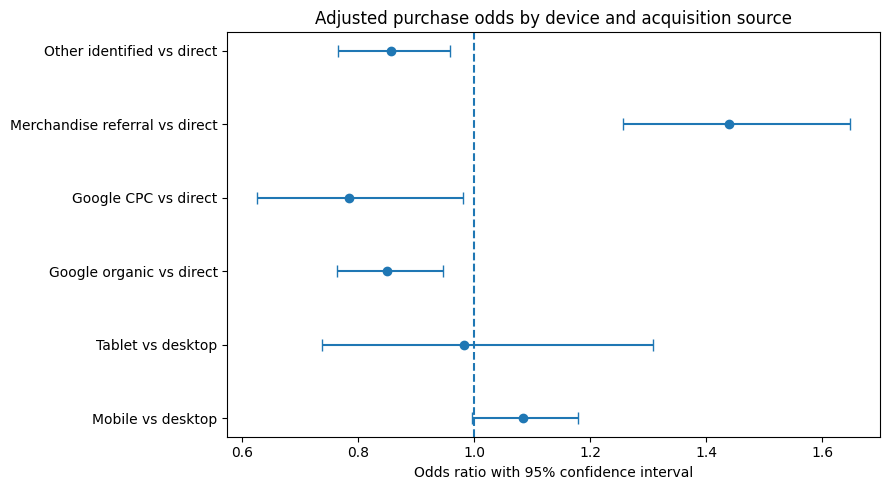

In [26]:
term_labels = {
    "C(device_category, Treatment(reference='desktop'))[T.mobile]":
        "Mobile vs desktop",
    "C(device_category, Treatment(reference='desktop'))[T.tablet]":
        "Tablet vs desktop",
    "C(source_group, Treatment(reference='Direct'))[T.Google organic]":
        "Google organic vs direct",
    "C(source_group, Treatment(reference='Direct'))[T.Google CPC]":
        "Google CPC vs direct",
    "C(source_group, Treatment(reference='Direct'))[T.Merchandise referral]":
        "Merchandise referral vs direct",
    "C(source_group, Treatment(reference='Direct'))[T.Other identified]":
        "Other identified vs direct",
}

clean_logit_results = (
    logit_results[
        logit_results["term"] != "Intercept"
    ]
    .copy()
)

clean_logit_results["comparison"] = (
    clean_logit_results["term"].map(term_labels)
)

clean_logit_results = clean_logit_results[
    [
        "comparison",
        "odds_ratio",
        "odds_ratio_ci_lower",
        "odds_ratio_ci_upper",
        "p_value",
        "statistically_significant",
    ]
].reset_index(drop=True)

clean_logit_display = clean_logit_results.round(
    {
        "odds_ratio": 4,
        "odds_ratio_ci_lower": 4,
        "odds_ratio_ci_upper": 4,
    }
)

clean_logit_display["p_value"] = (
    clean_logit_results["p_value"].map(format_p_value)
)

display(clean_logit_display)


plot_data = clean_logit_results.copy()
positions = np.arange(len(plot_data))

lower_errors = (
    plot_data["odds_ratio"]
    - plot_data["odds_ratio_ci_lower"]
)

upper_errors = (
    plot_data["odds_ratio_ci_upper"]
    - plot_data["odds_ratio"]
)

plt.figure(figsize=(9, 5))

plt.errorbar(
    x=plot_data["odds_ratio"],
    y=positions,
    xerr=np.vstack([lower_errors, upper_errors]),
    fmt="o",
    capsize=4,
)

plt.axvline(
    x=1,
    linestyle="--",
)

plt.yticks(
    positions,
    plot_data["comparison"],
)

plt.xlabel("Odds ratio with 95% confidence interval")
plt.ylabel("")
plt.title("Adjusted purchase odds by device and acquisition source")
plt.tight_layout()
plt.show()

## 7. Findings and limitations

## Key findings

### Funnel performance

The chronological session funnel contained 77,020 product-view sessions,
of which 15,167 progressed to cart, 5,416 progressed to checkout, and
2,834 completed a purchase. The resulting product-view-to-purchase
conversion rate was 3.68%.

The largest loss occurred between product view and add to cart, where
80.31% of product-view sessions did not progress. View-to-cart conversion
was similar across desktop, mobile, and tablet, indicating that this
friction was present across device categories rather than being isolated
to a mobile experience problem.

### Device comparison

Mobile sessions converted at 3.84%, compared with 3.57% for desktop
sessions. The two-proportion z-test produced an unadjusted p-value of
0.0531 and a Benjamini-Hochberg-adjusted p-value of 0.0796.

The cluster-robust logistic regression also found that mobile purchase
odds were approximately 8.5% higher than desktop purchase odds, but the
95% confidence interval included 1 and the result was not statistically
significant (p = 0.0586). Therefore, the analysis does not provide
sufficient evidence to conclude that mobile outperforms desktop.

### Acquisition-source comparison

Google organic and Google CPC conversion rates were 3.11% and 2.87%,
respectively. Their direct comparison was not statistically significant
after multiple-testing correction.

After controlling for device category, both Google organic and Google CPC
had lower purchase odds than direct traffic. The adjusted odds ratios were
0.85 for Google organic and 0.78 for Google CPC.

The Google Merchandise Store referral segment had a 5.16% conversion rate
and significantly higher purchase odds than direct traffic. Because the
referring domain appears related to the analyzed property, this result
may reflect self-referral or attribution configuration issues. It should
be investigated as a measurement-quality finding rather than interpreted
as evidence of superior acquisition performance.

## Product recommendation

Prioritize investigation of the product-view-to-cart transition across
all devices. Because view-to-cart conversion is consistently near 19% to
20% across device categories, the first experiment should target shared
product-page or cart-entry friction rather than a device-specific redesign.

Potential experiment areas include:

- Clarifying product value and product-detail information
- Increasing the visibility of the add-to-cart action
- Reviewing product availability, pricing, and shipping messaging
- Reducing interaction steps between product view and cart
- Validating referral and campaign attribution before reallocating
  acquisition spend

## Limitations

- The GA4 sample is obfuscated and covers only three months.
- The analysis is observational and does not establish causal effects.
- Traffic-source fields represent first-user acquisition information and
  may not describe the source responsible for each individual session.
- Some source values are deleted or grouped into generic categories.
- The referral result may be influenced by self-referral or attribution
  configuration.
- Individual users may generate multiple sessions. Logistic-regression
  standard errors were therefore clustered by user, while the simpler
  two-proportion tests remain session-level comparisons.
- The statistical comparisons were predefined and adjusted for multiple
  testing, but additional exploratory comparisons would require further
  correction.